# Mini Batch Gradient Descent

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# dataset loading
from sklearn.datasets import load_diabetes
x,y = load_diabetes(return_X_y=True)

In [3]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [4]:
# sklearn for comparison
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_sk = lr.predict(x_test)

from sklearn.metrics import r2_score
r2_sk = r2_score(y_test, y_pred_sk)
print('R2_score sklearn =',r2_sk)
print('Intercept =',lr.intercept_)
print('Coefficients =',lr.coef_)

R2_score sklearn = 0.4399338661568968
Intercept = 151.88331005254167
Coefficients = [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]


In [18]:
# custom class mini_batch gd
class mini_batch:
    def __init__(self, learning_rate, epochs, batch_size):
        self.epochs = epochs
        self.loss_list = []
        self.n = learning_rate
        self.intercept_ = None
        self.coef_ = None
        self.batch_size = batch_size
    
    def fit(self, x_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            for j in range(int(x_train.shape[0]/self.batch_size)):      # i.e number of batches
                # assuming x is batch size, hence selectig x random rows to put in batch
                # random.sample(list name, x) method
                # returns x random elements from the list mentioned
                idx = random.sample(range(x_train.shape[0]), self.batch_size)

                # vectorization
                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_)     # array with 10 elements

                # update intercept
                grad_intercept = (-2/self.batch_size) * np.sum(y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept)

                # update coef
                grad_coef = (-2/self.batch_size) * np.dot((y_train[idx] - y_pred), x_train[idx])
                self.coef_ -= (self.n * grad_coef)
            
            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        
        print('Final parameters...')
        print('Intercept =',self.intercept_)
        print('Coefficients =',self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [19]:
import time

In [28]:
gd = mini_batch(0.1,1000, 35)
start = time.time()
gd.fit(x_train, y_train)
print('Training time :',time.time() - start)

step 0 | loss = 6075.3957254362895
step 1 | loss = 5845.83892574132
step 2 | loss = 5782.498711637912
step 3 | loss = 5700.3896483225735
step 4 | loss = 5639.440341271168
step 5 | loss = 5574.8462903680365
step 6 | loss = 5533.36040376374
step 7 | loss = 5450.5553074682575
step 8 | loss = 5389.97395713996
step 9 | loss = 5372.592435745375
step 10 | loss = 5278.692706871985
step 11 | loss = 5223.671928565487
step 12 | loss = 5164.679314333744
step 13 | loss = 5104.536371244012
step 14 | loss = 5059.729486096671
step 15 | loss = 5014.817558884954
step 16 | loss = 4960.354527546837
step 17 | loss = 4919.745325272189
step 18 | loss = 4869.889745728564
step 19 | loss = 4823.587055378184
step 20 | loss = 4786.75425179469
step 21 | loss = 4745.761058248662
step 22 | loss = 4707.274721907661
step 23 | loss = 4673.976476600349
step 24 | loss = 4633.5013472646415
step 25 | loss = 4602.523127447926
step 26 | loss = 4559.484063192723
step 27 | loss = 4538.1220025374005
step 28 | loss = 4480.745719

In [29]:
# evaluation
y_pred_cc = gd.predict(x_test)
r2_cc = r2_score(y_test, y_pred_cc)
print(r2_cc)

0.44398097841478656


In [33]:
gd2 = mini_batch(0.1,100, 35)
start = time.time()
gd2.fit(x_train, y_train)
print('Training time :',time.time() - start)

step 0 | loss = 6313.943764806509
step 1 | loss = 5853.999144707227
step 2 | loss = 5788.765313851363
step 3 | loss = 5748.381433566961
step 4 | loss = 5652.9807000422115
step 5 | loss = 5566.3233354920685
step 6 | loss = 5492.913584666071
step 7 | loss = 5449.692053780853
step 8 | loss = 5367.3622570535135
step 9 | loss = 5292.707149526725
step 10 | loss = 5301.836914692236
step 11 | loss = 5186.488879792503
step 12 | loss = 5133.627225138168
step 13 | loss = 5088.509527165319
step 14 | loss = 5039.297654815337
step 15 | loss = 4992.086277477316
step 16 | loss = 4933.557074267037
step 17 | loss = 4884.5238797324355
step 18 | loss = 4841.524835650523
step 19 | loss = 4796.844983222073
step 20 | loss = 4751.589789594618
step 21 | loss = 4711.413503299804
step 22 | loss = 4671.164265794005
step 23 | loss = 4677.343779587513
step 24 | loss = 4595.968766179443
step 25 | loss = 4552.796586478768
step 26 | loss = 4533.42539599255
step 27 | loss = 4482.662254631932
step 28 | loss = 4446.51572

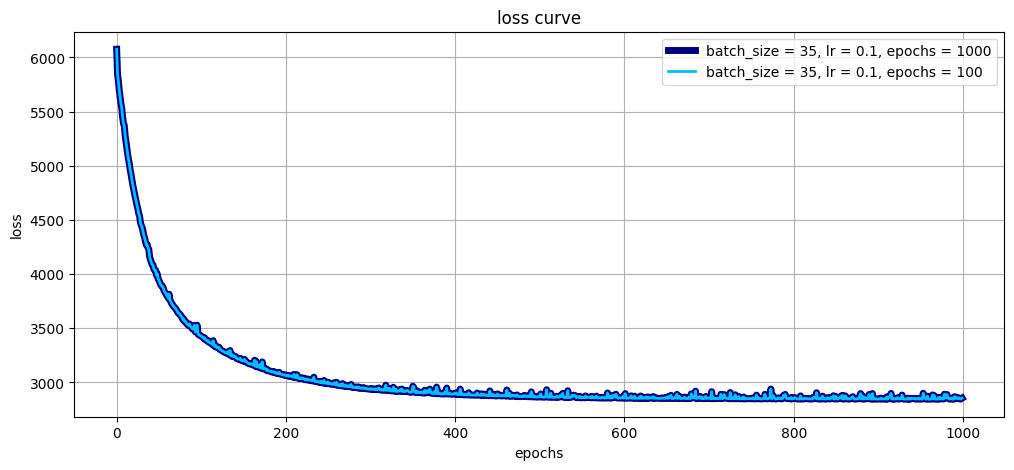

In [38]:
# loss curve
plt.figure(figsize=(12,5))
plt.plot(range(gd.epochs), gd.loss_list, color = 'navy', lw = 5, label = 'batch_size = 35, lr = 0.1, epochs = 1000')
plt.plot(range(gd.epochs), gd.loss_list, color = 'deepskyblue', lw = 2, label = 'batch_size = 35, lr = 0.1, epochs = 100')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss curve')
plt.grid(True)
plt.legend()
plt.show()